In [2]:
import cupy as np
import math
import matplotlib.pyplot as plt
import scipy as sc
import importlib
import sys
from tqdm import tqdm
sys.path.append('..')
import collision_cp_scars
importlib.reload(collision_cp_scars)
from collision_cp_scars import generate_spectrum, wigner_smith_matrix, wigner_smith_matrix_single, thermal_time_delay, relative_MB_weights, S_matrix
from scipy.signal import find_peaks

# parameters
e_mass = 5.48579909e-4    # electron mass in amu
t0 = 315775               # a.u. to K
tau0 = 2.418884326509e-17 # a.u. to sec

In [3]:
# parameters
e_mass = 5.48579909e-4    # electron mass in amu
t0 = 315775               # a.u. to K
tau0 = 2.418884326509e-17 # a.u. to sec

# define properties of molecules
reduced_masses = {"NaKNaK" : 62 / 2, "RbKRb" : 87 * (87 + 40) / (87 + 87 + 40)}     # amu
van_der_wall_coeffs = {"NaKNaK" : 561070, "RbKRb" : 8000}      # a.u.

molecules = "RbCsRbCs"
mu = 51 / e_mass      # now in a.u.
c6 = 7700         # a.u.

abar = (np.pi * 2 ** (-3/2) / math.gamma(5/4) / math.gamma(1/2)) ** 2
print(np.pi ** 2 * abar ** 2)

# define natural units
beta = (2 * mu * c6) ** (1/4)    # length 
E_beta = 1 / (2 * mu * beta ** 2)   # energy
tau_beta = 2 * np.pi / E_beta    # time
print("reduced mass", mu)
print("C6", c6)
print("beta (a0)", beta)
print("abar (a0)", beta * abar)
print("E_beta (uK)", E_beta * t0 * 1e6)
print("tau_beta (s)", tau_beta * tau0)

2.254940993669586
reduced mass 92967.31280765879
C6 7700
beta (a0) 194.51932314094483
abar (a0) 92.97805735595517
E_beta (uK) 44.88404310178714
tau_beta (s) 1.0692536510917182e-06


In [4]:
scale = 1

# properties of resonant spectrum
rrkm = 0.39e-3 / 3e2     # seconds
dos = rrkm / tau0 / 2 / np.pi * E_beta
mean_spacing = 1 / dos / scale
print("mean spacing (E6)", mean_spacing)

# thermal properties
temp = 1 / scale       # in terms of E6
num_resonances = 1000        # should be odd
print("T/d", temp / mean_spacing)

rrkm_c6 = 2 * np.pi / mean_spacing 
print("RRKM (tau_beta)", rrkm_c6)
print("RRKM (s)", rrkm_c6 * tau_beta * tau0 / scale)

mean spacing (E6) 0.8225028085320909
T/d 1.2158013196145625
RRKM (tau_beta) 7.639104987851772
RRKM (s) 8.168140899333462e-06


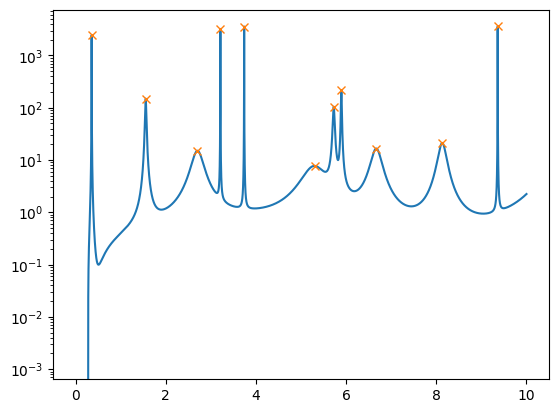

11
82999
9.361262425248505


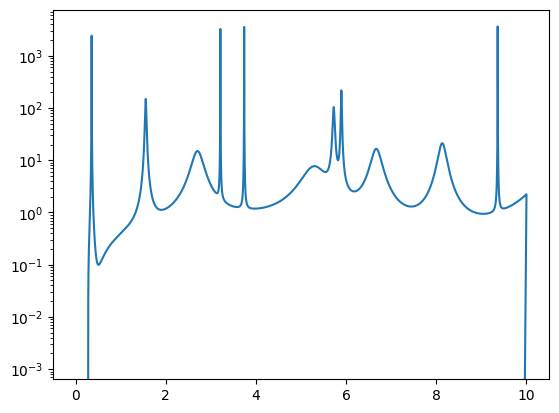

In [5]:
mean_x = np.array([1])
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)

energy_grid = np.linspace(0, 10, 50000)[1:]
dE = energy_grid[1] - energy_grid[0]
time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))

peaks, _ = find_peaks(time_delays.get(), height=1)
plt.semilogy(energy_grid.get(), time_delays.get())
plt.semilogy(energy_grid[peaks].get(), time_delays[peaks].get(), "x")
# plt.plot(energy_grid.get(), relative_MB_weights(temp, energy_grid).get() * np.max(peaks) * 10)
# plt.xlim(0, 2)
# plt.ylim(0, 5000)
plt.show()

# break

new_energies = np.array([])
peak_vals = energy_grid[peaks]
print(len(peaks))

insert = np.array([i * dE / 500 for i in range(500)])

new_energies = np.zeros(100000)
index = 0
new_index = 0
added = 0
for peak in peaks:

    i = peak - 3

    new_energies[new_index:new_index + (i - index)] = energy_grid[index:i]
    new_index = new_index + (i - index)
    index = peak + 3

    for j in range(6):
        new_energies[new_index:new_index + 500] = energy_grid[i+j] + insert
        new_index = new_index + 500
        added += 500

num_grid = len(energy_grid)
new_energies[new_index:new_index + (num_grid - index)] = energy_grid[index:num_grid]

new_energies = new_energies[:num_grid + added]

print(len(new_energies))
# new_energies = np.array(new_energies)

new_time_delays = wigner_smith_matrix(new_energies, energy_GOE_mat, np.square(W_mat))
print(new_energies[np.argmax(new_time_delays)])
plt.semilogy(new_energies.get(), new_time_delays.get())
# plt.ylim(0, 1000)
# plt.xlim(0, 2)
plt.show()

(array([3000.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
          20.]),
 array([4.00008000e-07, 2.03604072e-05, 4.03208064e-05, 6.02812056e-05,
        8.02416048e-05, 1.00202004e-04, 1.20162403e-04, 1.40122802e-04,
        1.60083202e-04, 1.80043601e-04, 2.00004000e-04]),
 <BarContainer object of 10 artists>)

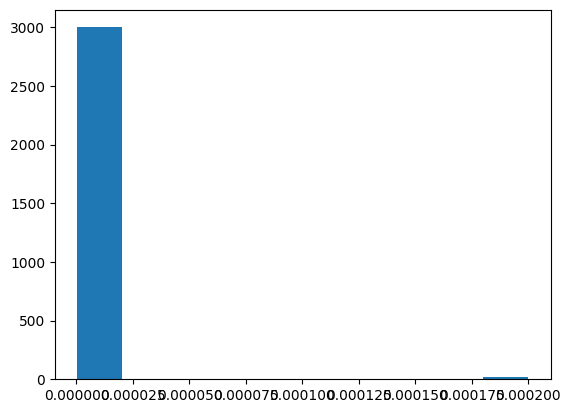

In [84]:
plt.hist((new_energies[3542-10+1:3542+3000+10+1] - new_energies[3542-10:3542+3000+10]).get())

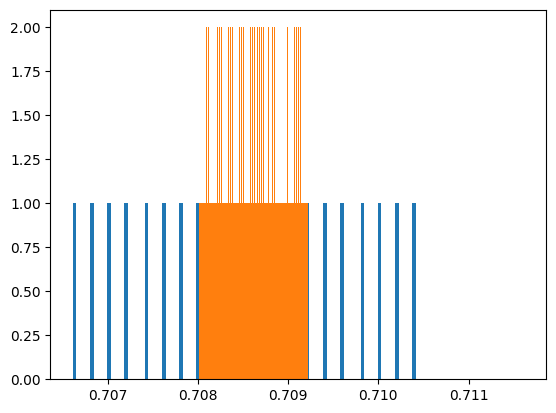

In [82]:
plt.hist(energy_grid[3542-10:3542+10].get(), bins=100)
plt.hist(new_energies[3542-10:3542+3000+10].get(), bins=10000)
plt.show()

In [ ]:
total_delay = []

for i in tqdm(range(len(total_delay), 100)):
    energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)
    time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
    
    peaks, _ = find_peaks(time_delays.get(), height=10)

    new_energies = np.array([])
    peak_vals = energy_grid[peaks]

    insert = np.array([i * dE / 500 for i in range(500)])
    
    new_energies = np.zeros(150000)
    index = 0
    new_index = 0
    added = 0
    for peak in peaks:

        i = peak - 3

        new_energies[new_index:new_index + (i - index)] = energy_grid[index:i]
        new_index = new_index + (i - index)
        index = peak + 3

        for j in range(6):
            new_energies[new_index:new_index + 500] = energy_grid[i+j] + insert
            new_index = new_index + 500
            added += 500

    num_grid = len(energy_grid)
    new_energies[new_index:new_index + (num_grid - index)] = energy_grid[index:num_grid]

    new_energies = new_energies[:new_index + (num_grid - index)]

    weights = relative_MB_weights(temp, new_energies) * wigner_smith_matrix(new_energies, energy_GOE_mat, np.square(W_mat))
    new_thermal_delay = np.append(new_energies[1:] - new_energies[:-1], dE) * weights

    total_delay.append(np.sum(new_thermal_delay).item())

100%|██████████| 100/100 [00:54<00:00,  1.83it/s]


In [108]:
import pickle
with open('no_sectors.pkl', 'wb') as f:
    pickle.dump(total_delay, f)

0.8225028085320909
0.13121087344756469
0.2970952343191198


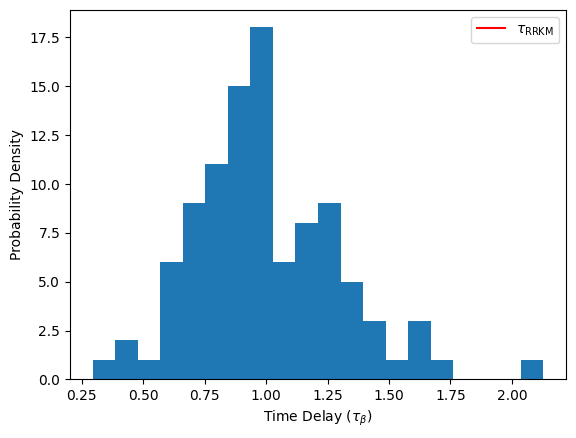

In [111]:

print(mean_spacing)
rrkm = 2 * np.pi / mean_spacing
rrkm_c6 = rrkm
normalized = np.array(total_delay).get() / rrkm_c6

plt.hist(normalized, bins=20)
print(np.mean(normalized) / rrkm_c6)
plt.xlabel(r"Time Delay ($\tau_\beta)$")
plt.ylabel("Probability Density")
print(np.std(normalized))
plt.legend([vline],[r"$\tau_{\text{RRKM}}$"])
plt.show()

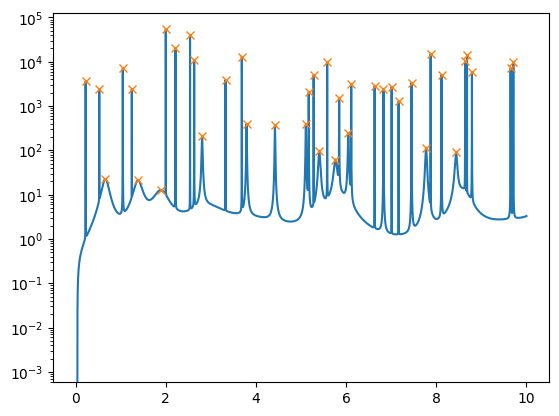

39
143365
1.2470619412388246
3.228306761949576


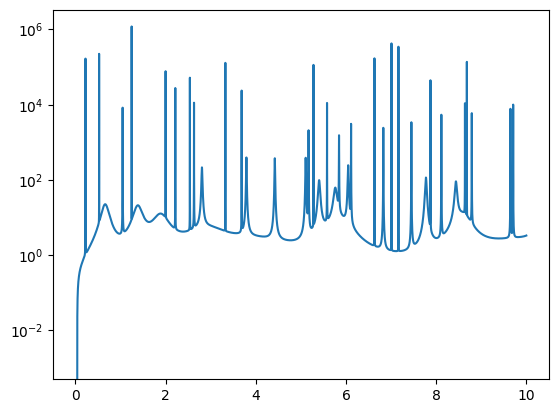

In [62]:
from scipy.signal import find_peaks

mean_x = np.array([1, 0.1, 0.1])
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

energy_GOE_mat, W_mat, x_actual = generate_spectrum(100, mean_spacing, mean_coupling_strength)

energy_GOE_mat = energy_store
W_mat = W_store

energy_grid = np.linspace(0, 10, 50000)[1:]
dE = energy_grid[1] - energy_grid[0]
time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))

peaks, _ = find_peaks(time_delays.get(), height=10)
plt.semilogy(energy_grid.get(), time_delays.get())
plt.semilogy(energy_grid[peaks].get(), time_delays[peaks].get(), "x")
# plt.plot(energy_grid.get(), relative_MB_weights(temp, energy_grid).get() * np.max(peaks) * 10)
# plt.xlim(0, 2)
# plt.ylim(0, 5000)
plt.show()

# break

new_energies = np.array([])
peak_vals = energy_grid[peaks]
print(len(peaks))

density = 400
insert = np.array([i * dE / density for i in range(density)])

new_energies = np.zeros(1000000)
index = 0
new_index = 0
added = 0
for peak in peaks:

    i = peak - 3

    new_energies[new_index:new_index + (i - index)] = energy_grid[index:i]
    new_index = new_index + (i - index)
    index = peak + 3

    for j in range(6):
        new_energies[new_index:new_index + density] = energy_grid[i+j] + insert
        new_index = new_index + density
        added += density

num_grid = len(energy_grid)
new_energies[new_index:new_index + (num_grid - index)] = energy_grid[index:num_grid]

new_energies = new_energies[:new_index + (num_grid - index)]

print(len(new_energies))
# new_energies = np.array(new_energies)

new_time_delays = wigner_smith_matrix(new_energies, energy_GOE_mat, np.square(W_mat))
delay = np.sum(np.append(new_energies[1:] - new_energies[:-1], dE) * relative_MB_weights(temp, new_energies) * new_time_delays).item() / rrkm
print(new_energies[np.argmax(new_time_delays)])
print(delay)

plt.semilogy(new_energies.get(), new_time_delays.get())
# plt.ylim(0, 1000)
# plt.xlim(0, 2)
plt.show()

In [65]:
total_delay = []

mean_x = np.array([1, 0.1, 0.01, 0.001])
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

for i in tqdm(range(len(total_delay), 100)):
    energy_GOE_mat, W_mat, x_actual = generate_spectrum(100, mean_spacing, mean_coupling_strength)
    time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
    
    peaks, _ = find_peaks(time_delays.get(), height=10)

    new_energies = np.array([])
    peak_vals = energy_grid[peaks]

    density = 1000
    insert = np.array([i * dE / density for i in range(density)])
    
    new_energies = np.zeros(1500000)
    index = 0
    new_index = 0
    added = 0
    for peak in peaks:

        i = peak - 3

        new_energies[new_index:new_index + (i - index)] = energy_grid[index:i]
        new_index = new_index + (i - index)
        index = peak + 3

        for j in range(6):
            new_energies[new_index:new_index + density] = energy_grid[i+j] + insert
            new_index = new_index + density
            added += density

    num_grid = len(energy_grid)
    new_energies[new_index:new_index + (num_grid - index)] = energy_grid[index:num_grid]

    new_energies = new_energies[:new_index + (num_grid - index)]

    weights = relative_MB_weights(temp, new_energies) * wigner_smith_matrix(new_energies, energy_GOE_mat, np.square(W_mat))
    new_thermal_delay = np.append(new_energies[1:] - new_energies[:-1], dE) * weights

    total_delay.append(np.sum(new_thermal_delay).item())

    rrkm = 2 * np.pi / mean_spacing
    if total_delay[-1] / rrkm > 6:
        energy_store = energy_GOE_mat
        W_store = W_mat

100%|██████████| 100/100 [00:49<00:00,  2.01it/s]


In [10]:
import pickle
with open('four_sectors_disconnected.pkl', 'wb') as f:
    pickle.dump(total_delay, f)

0.8225028085320909
0.5087805990049233
0.6202057427014748


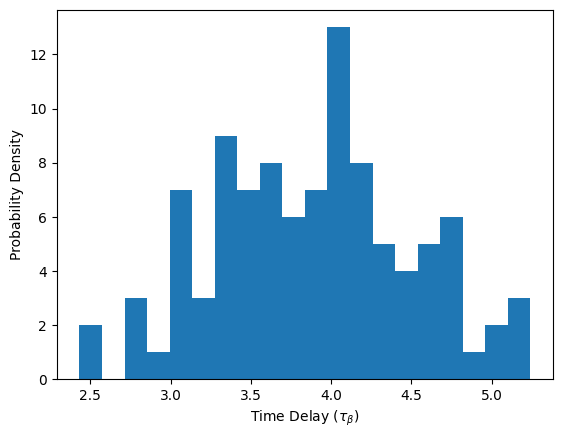

In [ ]:
print(mean_spacing)
rrkm = 2 * np.pi / mean_spacing
rrkm_c6 = rrkm
normalized = np.array(total_delay).get() / rrkm_c6

plt.hist(normalized, bins=20)
print(np.mean(normalized) / rrkm_c6)
plt.xlabel(r"Time Delay ($\tau_\beta)$")
plt.ylabel("Probability Density")
print(np.std(normalized))
plt.show()

In [90]:
H = np.array([[4, 0.01j],[-0.01j, 3]])
eigenvalues, eigenvectors = np.linalg.eigh(H) 
print(eigenvalues)
print(eigenvectors)
print(np.conj(eigenvectors.T) @ H @ eigenvectors)
W = np.array([1, 3])
print(eigenvectors @ W)
print(np.conj(eigenvectors.T) @ W)

[2.99990001 4.00009999]
[[0.0099985 +0.j         0.99995001+0.j        ]
 [0.        +0.99995001j 0.        -0.0099985j ]]
[[ 2.99990001e+00+0.j -3.21086799e-18+0.j]
 [-1.45606851e-18+0.j  4.00009999e+00+0.j]]
[3.00984854+0.j         0.        +0.96995451j]
[0.0099985 -2.99985004j 0.99995001+0.0299955j ]


In [5]:
importlib.reload(collision_cp_scars)
from collision_cp_scars import generate_spectrum_sectors_funnel
np.set_printoptions(linewidth=200)

mean_x = np.array([1, 0])
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

energy_GOE_mat, W_mat, x_actual = generate_spectrum_sectors_funnel(2, mean_spacing, mean_coupling_strength)
# time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
print(energy_GOE_mat)
print(W_mat)

[-0.5166901  0.5166901 -0.5598769  0.5598769]
[-0.74235066  0.4363485   0.          0.        ]


done


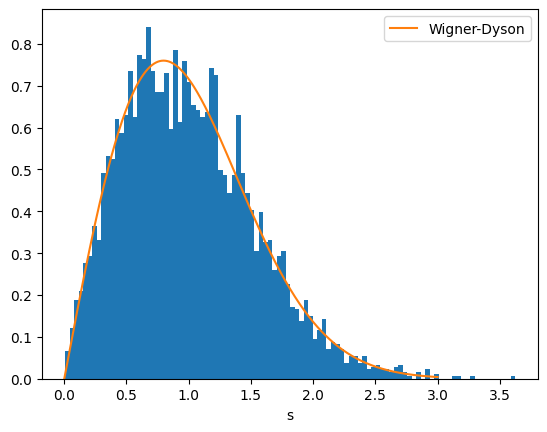

In [17]:
mean_x = np.array([1])
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

energy_GOE_mat, W_mat, x_actual = generate_spectrum_sectors_funnel(5000, mean_spacing, mean_coupling_strength)
sorted_energies = np.sort(energy_GOE_mat)
# print(energy_GOE_mat)
nn_diff = sorted_energies[1:] - sorted_energies[:-1]
# print(sorted_energies[0:3])
# print(nn_diff)
plt.hist(nn_diff.get() / mean_spacing, bins=100, density=True)
energy_range = np.linspace(0, 3, 1000)
wigner_dyson = np.pi / 2 * energy_range * np.exp(-np.pi * energy_range ** 2 / 4)
plt.plot(energy_range.get(), wigner_dyson.get(), label="Wigner-Dyson")
plt.xlabel("s")
plt.savefig("wigner-dyson.pdf")
plt.legend()
print("done")

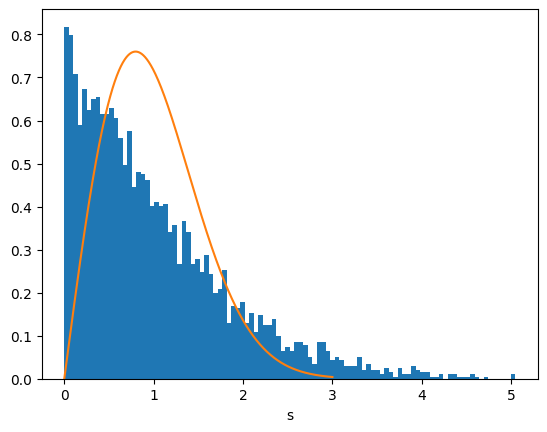

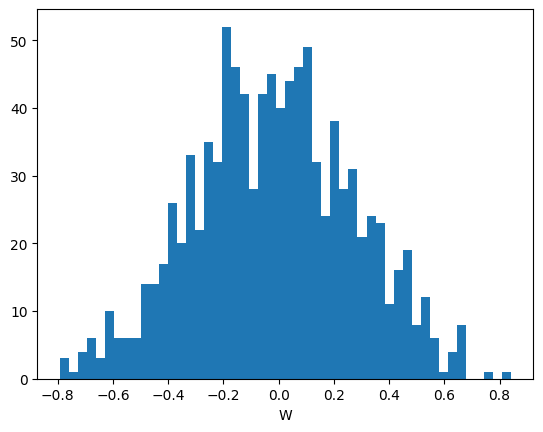

In [18]:
mean_x = np.array([1, 0, 0, 0])
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

energy_GOE_mat, W_mat, x_actual = generate_spectrum_sectors_funnel(1000, mean_spacing, mean_coupling_strength)
sorted_energies = np.sort(energy_GOE_mat)
# print(energy_GOE_mat)
nn_diff = sorted_energies[1:] - sorted_energies[:-1]
# print(sorted_energies[0:3])
# print(nn_diff)
plt.hist(nn_diff.get() / mean_spacing * len(mean_x), bins=100, density=True)
energy_range = np.linspace(0, 3, 1000)
wigner_dyson = np.pi / 2 * energy_range * np.exp(-np.pi * energy_range ** 2 / 4)
plt.plot(energy_range.get(), wigner_dyson.get(), label="Wigner-Dyson")
plt.xlabel("s")
plt.savefig("zero_coupling.pdf")
plt.show()

for i in range(1):
    plt.hist(W_mat[i*1000:(i+1)*1000].get(), bins=50)
    plt.xlabel("W")
    plt.savefig(f"zero_coupling_{i}.pdf")
    plt.show()

In [ ]:
mean_x = 1
sector_couplings = 0.1 * mean_spacing * np.ones(3)
mean_coupling_strength = np.array(np.append(np.sqrt(mean_x * mean_spacing / np.pi ** 2), sector_couplings))

energy_GOE_mat, W_mat, x_actual = generate_spectrum_sectors_funnel(1000, mean_spacing, mean_coupling_strength)
sorted_energies = np.sort(energy_GOE_mat)
# print(energy_GOE_mat)
nn_diff = sorted_energies[1:] - sorted_energies[:-1]
# print(sorted_energies[0:3])
# print(nn_diff)
plt.hist(nn_diff.get() / mean_spacing * len(mean_coupling_strength), bins=100, density=True)
energy_range = np.linspace(0, 3, 1000)
wigner_dyson = np.pi / 2 * energy_range * np.exp(-np.pi * energy_range ** 2 / 4)
plt.plot(energy_range.get(), wigner_dyson.get())
plt.xlabel("s")
plt.savefig("funnel_energies.pdf")
plt.show()

gauss = lambda x, mu, sigma: (1 / (sigma * (2 * 3.141592653589793)**0.5)) * \
                             (2.718281828459045 ** (-(x - mu)**2 / (2 * sigma**2)))

plt.hist(W_mat.get(), bins=100)
W_range = np.linspace(-1, 1, 500)
plt.plot(W_range, gauss(W_range, 0, mean_coupling_strength[0]))
plt.xlabel("W")
plt.savefig(f"funnel_couplings.pdf")
plt.show()

In [24]:
importlib.reload(collision_cp_scars)
from collision_cp_scars import generate_spectrum_sectors_cascade
np.set_printoptions(linewidth=200)

mean_x = np.array([1, 0.001, 0.001])
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

energy_GOE_mat, W_mat, x_actual = generate_spectrum_sectors_cascade(2, mean_spacing, mean_coupling_strength)
# time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
print(energy_GOE_mat)
print(W_mat)

[-0.82117085 -0.32549894 -0.31213335  0.32112564  0.48339603  0.65428147]
[ 0.12333623 -0.14476098  0.21176889 -0.00554439  0.2410992   0.16865159]


23.111675162857466


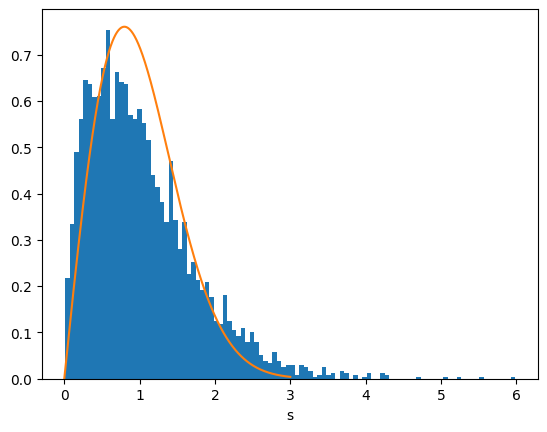

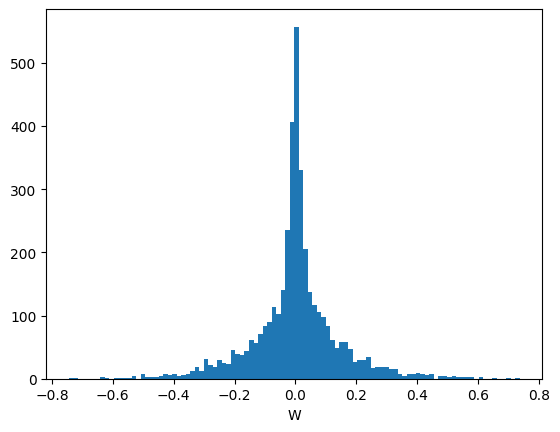

In [29]:
mean_x = 1
sector_couplings = 0.1 * mean_spacing * np.ones(3)
mean_coupling_strength = np.array(np.append(np.sqrt(mean_x * mean_spacing / np.pi ** 2), sector_couplings))

energy_GOE_mat, W_mat, x_actual = generate_spectrum_sectors_cascade(1000, mean_spacing, mean_coupling_strength)
sorted_energies = np.sort(energy_GOE_mat)
# print(energy_GOE_mat)
nn_diff = sorted_energies[1:] - sorted_energies[:-1]
# print(sorted_energies[0:3])
print(np.max(nn_diff))
nn_diff = nn_diff[nn_diff < 6 * mean_spacing / len(mean_coupling_strength)]
plt.hist(nn_diff.get() / mean_spacing * len(mean_coupling_strength), bins=100, density=True)
energy_range = np.linspace(0, 3, 1000)
wigner_dyson = np.pi / 2 * energy_range * np.exp(-np.pi * energy_range ** 2 / 4)
plt.plot(energy_range.get(), wigner_dyson.get())
plt.xlabel("s")
plt.savefig("cascade_energies.pdf")
plt.show()

plt.hist(W_mat.get(), bins=100)
plt.xlabel("W")
plt.savefig(f"cascade_couplings.pdf")
plt.show()

In [34]:
total_delay = []

sector_couplings = 0.1 * mean_spacing * np.ones(3)
mean_coupling_strength = np.array(np.append(np.sqrt(mean_x * mean_spacing / np.pi ** 2), sector_couplings))

energy_grid = np.linspace(0, 10, 50000)[1:]
dE = energy_grid[1] - energy_grid[0]

for i in tqdm(range(len(total_delay), 100)):
    energy_GOE_mat, W_mat, x_actual = generate_spectrum_sectors_funnel(100, mean_spacing, mean_coupling_strength)
    time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
    
    peaks, _ = find_peaks(time_delays.get(), height=10)

    new_energies = np.array([])
    peak_vals = energy_grid[peaks]

    density = 1000
    insert = np.array([i * dE / density for i in range(density)])
    
    new_energies = np.zeros(1500000)
    index = 0
    new_index = 0
    added = 0
    for peak in peaks:

        i = peak - 3

        new_energies[new_index:new_index + (i - index)] = energy_grid[index:i]
        new_index = new_index + (i - index)
        index = peak + 3

        for j in range(6):
            new_energies[new_index:new_index + density] = energy_grid[i+j] + insert
            new_index = new_index + density
            added += density

    num_grid = len(energy_grid)
    new_energies[new_index:new_index + (num_grid - index)] = energy_grid[index:num_grid]

    new_energies = new_energies[:new_index + (num_grid - index)]

    weights = relative_MB_weights(temp, new_energies) * wigner_smith_matrix(new_energies, energy_GOE_mat, np.square(W_mat))
    new_thermal_delay = np.append(new_energies[1:] - new_energies[:-1], dE) * weights

    total_delay.append(np.sum(new_thermal_delay).item())

    rrkm = 2 * np.pi / mean_spacing
    if total_delay[-1] / rrkm > 6:
        energy_store = energy_GOE_mat
        W_store = W_mat

100%|██████████| 100/100 [00:33<00:00,  2.95it/s]


In [36]:
import pickle
with open('funnel.pkl', 'wb') as f:
    pickle.dump(total_delay, f)

0.8225028085320909
0.5188686604510535
0.5132665830779722


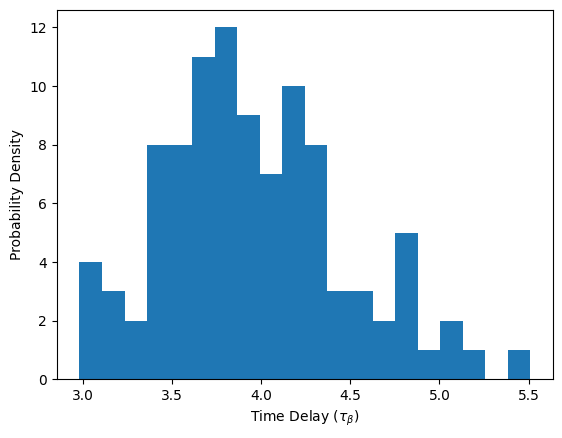

In [35]:
print(mean_spacing)
rrkm = 2 * np.pi / mean_spacing
rrkm_c6 = rrkm
normalized = np.array(total_delay).get() / rrkm_c6

plt.hist(normalized, bins=20)
print(np.mean(normalized) / rrkm_c6)
plt.xlabel(r"Time Delay ($\tau_\beta)$")
plt.ylabel("Probability Density")
print(np.std(normalized))
plt.show()

In [38]:
total_delay = []

sector_couplings = 0.1 * mean_spacing * np.ones(3)
mean_coupling_strength = np.array(np.append(np.sqrt(mean_x * mean_spacing / np.pi ** 2), sector_couplings))

energy_grid = np.linspace(0, 10, 50000)[1:]
dE = energy_grid[1] - energy_grid[0]

for i in tqdm(range(len(total_delay), 100)):
    energy_GOE_mat, W_mat, x_actual = generate_spectrum_sectors_cascade(100, mean_spacing, mean_coupling_strength)
    time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
    
    peaks, _ = find_peaks(time_delays.get(), height=10)

    new_energies = np.array([])
    peak_vals = energy_grid[peaks]

    density = 1000
    insert = np.array([i * dE / density for i in range(density)])
    
    new_energies = np.zeros(1500000)
    index = 0
    new_index = 0
    added = 0
    for peak in peaks:

        i = peak - 3

        new_energies[new_index:new_index + (i - index)] = energy_grid[index:i]
        new_index = new_index + (i - index)
        index = peak + 3

        for j in range(6):
            new_energies[new_index:new_index + density] = energy_grid[i+j] + insert
            new_index = new_index + density
            added += density

    num_grid = len(energy_grid)
    new_energies[new_index:new_index + (num_grid - index)] = energy_grid[index:num_grid]

    new_energies = new_energies[:new_index + (num_grid - index)]

    weights = relative_MB_weights(temp, new_energies) * wigner_smith_matrix(new_energies, energy_GOE_mat, np.square(W_mat))
    new_thermal_delay = np.append(new_energies[1:] - new_energies[:-1], dE) * weights

    total_delay.append(np.sum(new_thermal_delay).item())

    rrkm = 2 * np.pi / mean_spacing
    if total_delay[-1] / rrkm > 6:
        energy_store = energy_GOE_mat
        W_store = W_mat

100%|██████████| 100/100 [00:32<00:00,  3.10it/s]


In [40]:
import pickle
with open('cascade.pkl', 'wb') as f:
    pickle.dump(total_delay, f)

0.8225028085320909
0.5248841831804949
0.5069616086494989


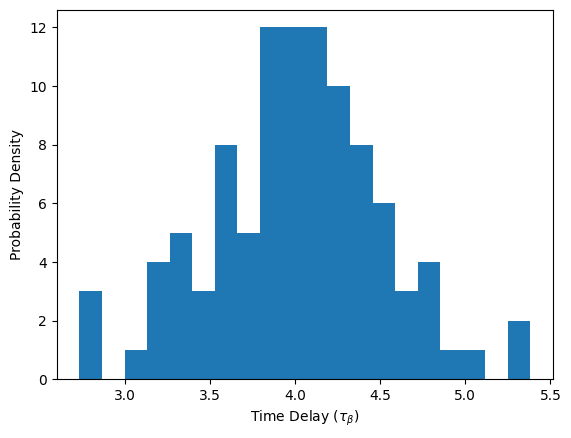

In [39]:
print(mean_spacing)
rrkm = 2 * np.pi / mean_spacing
rrkm_c6 = rrkm
normalized = np.array(total_delay).get() / rrkm_c6

plt.hist(normalized, bins=20)
print(np.mean(normalized) / rrkm_c6)
plt.xlabel(r"Time Delay ($\tau_\beta)$")
plt.ylabel("Probability Density")
print(np.std(normalized))
plt.show()